Initial data shape: (891, 12)

Missing Values Before
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate rows: 0

Missing Values After
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Age_median         0
Deck               0
Cabin_Missing      0
dtype: int64

Saved: train_cleaned.csv

New Features Created 
FamilySize, IsAlone, Title, AgeGroup, FarePerPerson, Fare_log, Age_log, FamilyCategory
Deck, Cabin_Missing (from earlier)


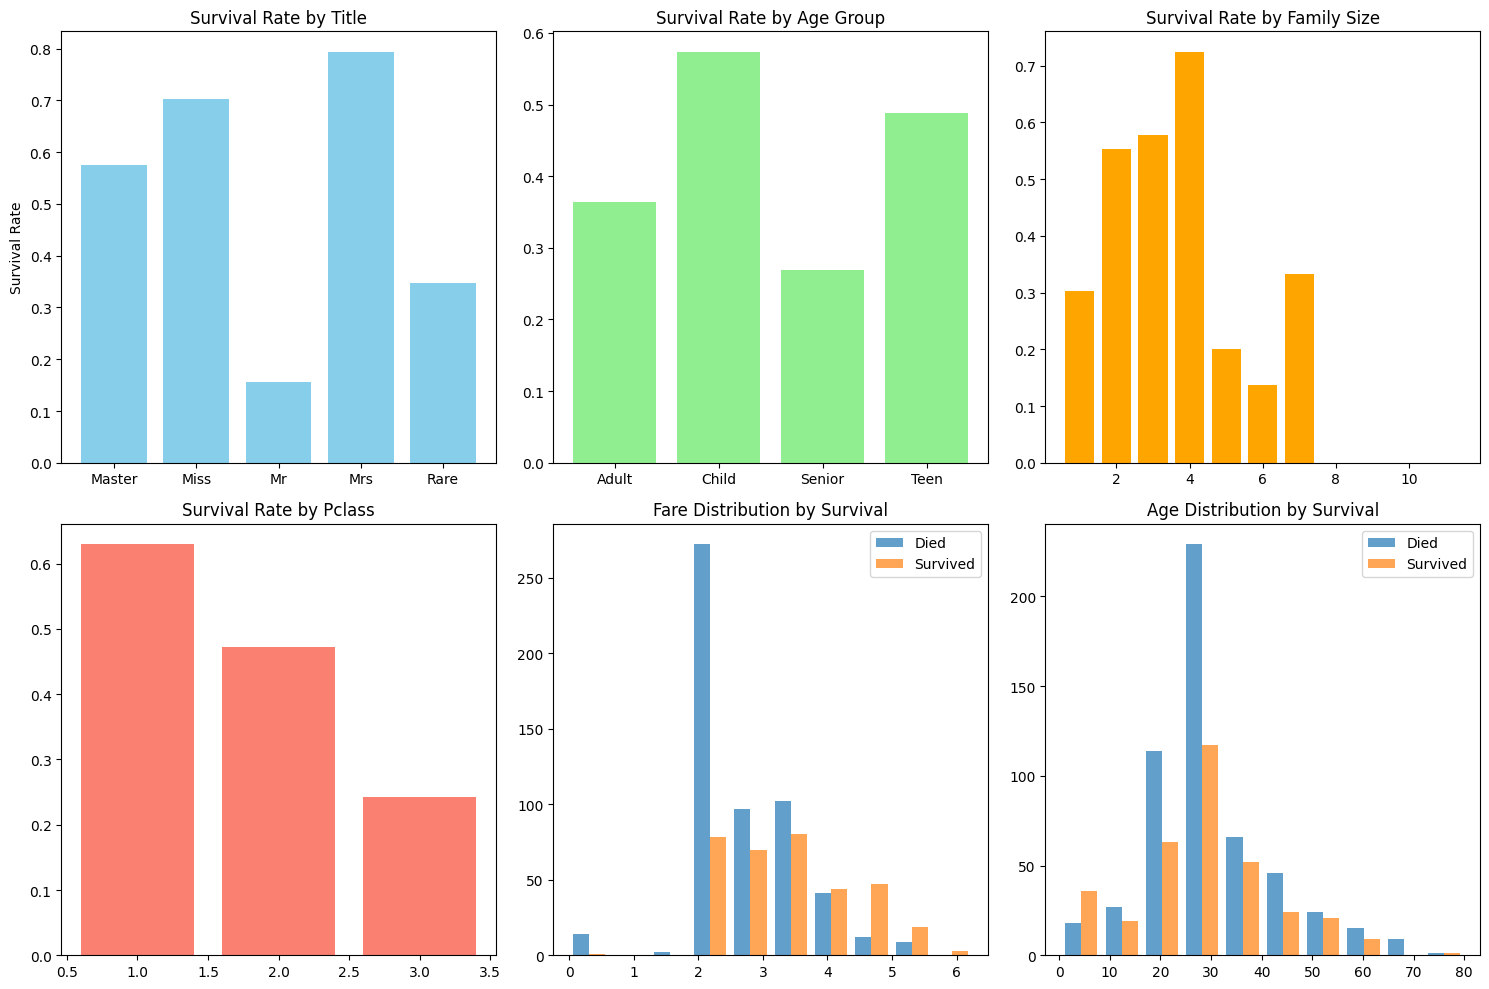


=== Feature Importance ===
          Feature  Importance
1             Age    0.196652
7   FarePerPerson    0.147688
4            Fare    0.143190
11       Title_Mr    0.132788
9        Sex_male    0.102082
5      FamilySize    0.042753
0          Pclass    0.042699
10     Title_Miss    0.037419
12      Title_Mrs    0.030340
2           SibSp    0.024069
21   Deck_Unknown    0.019926
8   Cabin_Missing    0.019307
3           Parch    0.018498
6         IsAlone    0.008527
13     Title_Rare    0.007897


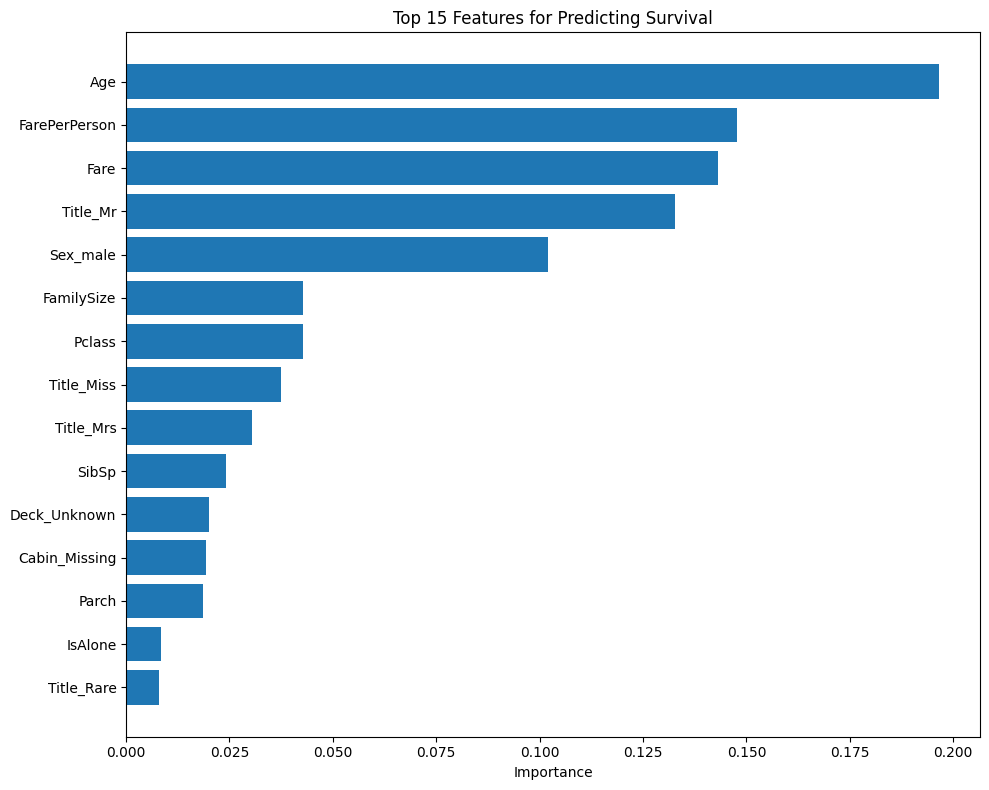


Final Selected Features for Model 
  - Title_Mrs
  - Sex_female
  - Title_Miss
  - Pclass
  - Fare
  - FamilySize
  - FarePerPerson
  - Title_Mr
  - Age
  - IsAlone

Justification:
1. Title_Mrs, Title_Miss, Sex_female: Women had higher survival rates
2. Pclass: Higher class = higher survival
3. Fare: Wealthier passengers survived more
4. FamilySize/IsAlone: Moderate family size had better survival
5. Age: Children and elderly had different survival patterns

Saved: train_prepared.csv


In [3]:
# Titanic Analysis - Assignment 2
# Complete Feature Engineering and Model Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Load data
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("Initial data shape:", train_df.shape)
train_df.head()

#  PART 1: MISSING VALUE HANDLING 

print("\n=== Missing Values Before ===")
print(train_df.isnull().sum())

# 1. Age: Fill with median
train_df['Age_median'] = train_df['Age'].median()
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# 2. Cabin: Extract Deck, create missing indicator
train_df['Deck'] = train_df['Cabin'].str[0]
train_df['Cabin_Missing'] = train_df['Cabin'].isnull().astype(int)
train_df['Deck'] = train_df['Deck'].fillna('Unknown')

# 3. Embarked: Fill with mode
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Check duplicates
print(f"\nDuplicate rows: {train_df.duplicated().sum()}")

print("\n=== Missing Values After ===")
print(train_df.isnull().sum())

# Save cleaned data
train_df.to_csv('../data/train_cleaned.csv', index=False)
print("\nSaved: train_cleaned.csv")

# PART 2: FEATURE ENGINEERING 

# 1. Family Size and IsAlone
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

# 2. Title extraction from Name
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
train_df['Title'] = train_df['Title'].map(title_mapping).fillna('Rare')

# 3. Age groups
def age_group(age):
    if age < 12: return 'Child'
    elif age < 18: return 'Teen'
    elif age < 60: return 'Adult'
    else: return 'Senior'
train_df['AgeGroup'] = train_df['Age'].apply(age_group)

# 4. Fare per person
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']

# 5. Log transform Fare and Age
train_df['Fare_log'] = np.log1p(train_df['Fare'])
train_df['Age_log'] = np.log1p(train_df['Age'])

# 6. Pclass as ordinal (already numeric)

# 7. Family category
def family_category(size):
    if size == 1: return 'Alone'
    elif size <= 4: return 'Small'
    else: return 'Large'
train_df['FamilyCategory'] = train_df['FamilySize'].apply(family_category)

print("\n=== New Features Created ===")
print(f"FamilySize, IsAlone, Title, AgeGroup, FarePerPerson, Fare_log, Age_log, FamilyCategory")
print(f"Deck, Cabin_Missing (from earlier)")

#  PART 3: VISUALIZATIONS 

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Survival by Title
title_survival = train_df.groupby('Title')['Survived'].mean()
axes[0,0].bar(title_survival.index, title_survival.values, color='skyblue')
axes[0,0].set_title('Survival Rate by Title')
axes[0,0].set_ylabel('Survival Rate')

# Survival by AgeGroup
age_survival = train_df.groupby('AgeGroup')['Survived'].mean()
axes[0,1].bar(age_survival.index, age_survival.values, color='lightgreen')
axes[0,1].set_title('Survival Rate by Age Group')

# Survival by FamilySize
family_survival = train_df.groupby('FamilySize')['Survived'].mean()
axes[0,2].bar(family_survival.index, family_survival.values, color='orange')
axes[0,2].set_title('Survival Rate by Family Size')

# Survival by Pclass
pclass_survival = train_df.groupby('Pclass')['Survived'].mean()
axes[1,0].bar(pclass_survival.index, pclass_survival.values, color='salmon')
axes[1,0].set_title('Survival Rate by Pclass')

# Fare distribution by survival
axes[1,1].hist([train_df[train_df['Survived']==0]['Fare_log'], 
                train_df[train_df['Survived']==1]['Fare_log']], 
               label=['Died', 'Survived'], alpha=0.7)
axes[1,1].set_title('Fare Distribution by Survival')
axes[1,1].legend()

# Age distribution by survival
axes[1,2].hist([train_df[train_df['Survived']==0]['Age'], 
                train_df[train_df['Survived']==1]['Age']], 
               label=['Died', 'Survived'], alpha=0.7)
axes[1,2].set_title('Age Distribution by Survival')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# PART 4: FEATURE SELECTION 

# Prepare features for modeling
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 
            'IsAlone', 'FarePerPerson', 'Title', 'Deck', 'Cabin_Missing']

# Encode categorical variables
train_encoded = pd.get_dummies(train_df[features], columns=['Sex', 'Title', 'Deck'], drop_first=True)

# Add target
X = train_encoded
y = train_df['Survived']

# Remove any remaining NaN
X = X.fillna(0)

# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(importance_df.head(15))

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(15)['Feature'], importance_df.head(15)['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features for Predicting Survival')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#  FINAL SELECTED FEATURES 

# Keep top features + essential ones
selected_features = [
    'Title_Mrs', 'Sex_female', 'Title_Miss', 'Pclass', 'Fare', 
    'FamilySize', 'FarePerPerson', 'Title_Mr', 'Age', 'IsAlone'
]

print("\n=== Final Selected Features for Model ===")
for f in selected_features:
    print(f"  - {f}")

print("\nJustification:")
print("1. Title_Mrs, Title_Miss, Sex_female: Women had higher survival rates")
print("2. Pclass: Higher class = higher survival")
print("3. Fare: Wealthier passengers survived more")
print("4. FamilySize/IsAlone: Moderate family size had better survival")
print("5. Age: Children and elderly had different survival patterns")

# SAVE PREPARED DATA 
train_encoded.to_csv('../data/train_prepared.csv', index=False)
print("\nSaved: train_prepared.csv")